In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df=pd.read_csv(r"C:\Users\CC\Downloads\netflix\netflixData.csv")
print(df)

                                   Show Id                          Title  \
0     cc1b6ed9-cf9e-4057-8303-34577fb54477                       (Un)Well   
1     e2ef4e91-fb25-42ab-b485-be8e3b23dedb                         #Alive   
2     b01b73b7-81f6-47a7-86d8-acb63080d525  #AnneFrank - Parallel Stories   
3     b6611af0-f53c-4a08-9ffa-9716dc57eb9c                       #blackAF   
4     7f2d4170-bab8-4d75-adc2-197f7124c070               #cats_the_mewvie   
...                                    ...                            ...   
5962  62b8b682-f191-4c10-aa04-32319329bd8d                      الف مبروك   
5963  5bed77ab-5e31-4216-8b51-44c9a35442e6                   دفعة القاهرة   
5964  4661ec0c-8692-4661-bc76-a96412b311fd                           海的儿子   
5965  145c93a7-1924-403c-a933-4ede8ad66f26                        반드시 잡는다   
5966  d4613d34-cb71-4bd6-b570-fa857f02c44d            최강전사 미니특공대 : 영웅의 탄생   

                                            Description  \
0     This docus

In [14]:
#info of all data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5967 entries, 0 to 5966
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Show Id             5967 non-null   str    
 1   Title               5967 non-null   str    
 2   Description         5967 non-null   str    
 3   Director            3903 non-null   str    
 4   Genres              5967 non-null   str    
 5   Cast                5437 non-null   str    
 6   Production Country  5408 non-null   str    
 7   Release Date        5964 non-null   float64
 8   Rating              5963 non-null   str    
 9   Duration            5964 non-null   str    
 10  Imdb Score          5359 non-null   str    
 11  Content Type        5967 non-null   str    
 12  Date Added          4632 non-null   str    
dtypes: float64(1), str(12)
memory usage: 606.2 KB


In [15]:
#to see null values
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director              2064
Genres                   0
Cast                   530
Production Country     559
Release Date             3
Rating                   4
Duration                 3
Imdb Score             608
Content Type             0
Date Added            1335
dtype: int64

In [16]:
#set release date in year format
df['Release Date'] = pd.to_datetime( df['Release Date'].astype(str).str.replace('.0',''), format='%Y',)
print(df)

                                   Show Id                          Title  \
0     cc1b6ed9-cf9e-4057-8303-34577fb54477                       (Un)Well   
1     e2ef4e91-fb25-42ab-b485-be8e3b23dedb                         #Alive   
2     b01b73b7-81f6-47a7-86d8-acb63080d525  #AnneFrank - Parallel Stories   
3     b6611af0-f53c-4a08-9ffa-9716dc57eb9c                       #blackAF   
4     7f2d4170-bab8-4d75-adc2-197f7124c070               #cats_the_mewvie   
...                                    ...                            ...   
5962  62b8b682-f191-4c10-aa04-32319329bd8d                      الف مبروك   
5963  5bed77ab-5e31-4216-8b51-44c9a35442e6                   دفعة القاهرة   
5964  4661ec0c-8692-4661-bc76-a96412b311fd                           海的儿子   
5965  145c93a7-1924-403c-a933-4ede8ad66f26                        반드시 잡는다   
5966  d4613d34-cb71-4bd6-b570-fa857f02c44d            최강전사 미니특공대 : 영웅의 탄생   

                                            Description  \
0     This docus

In [17]:
#convert it into date time
df['Date Added'] = pd.to_datetime(df['Date Added'], )
print(df['Date Added'])

0             NaT
1      2020-09-08
2      2020-07-01
3             NaT
4      2020-02-05
          ...    
5962   2020-04-25
5963          NaT
5964          NaT
5965   2018-02-28
5966   2018-09-01
Name: Date Added, Length: 5967, dtype: datetime64[us]


In [18]:
df[df['Release Date'].isnull()]

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
2790,8d2c9141-8232-4d3d-b68e-f65a6aff2b54,Louis C.K. 2017,"Louis C.K. muses on religion, eternal love, gi...",Louis C.K.,Movies,Louis C.K.,United States,NaT,NaN,NaN,NaN,TV Show,NaT
2791,17fd533b-799e-4d68-8af5-03ba8c14da0a,Louis C.K.: Hilarious,Emmy-winning comedy writer Louis C.K. brings h...,Louis C.K.,Movies,Louis C.K.,United States,NaT,NaN,NaN,NaN,TV Show,NaT
2792,0418aab9-53ba-46af-8a5e-fff8fdd52684,Louis C.K.: Live at the Comedy Store,The comic puts his trademark hilarious/thought...,Louis C.K.,Movies,Louis C.K.,United States,NaT,NaN,NaN,NaN,TV Show,NaT


In [19]:
#set score in float
df['Imdb Score'] = ( df['Imdb Score'] .astype(str) .str.replace('/10',''))

df['Imdb Score'] = pd.to_numeric(df['Imdb Score'], errors='coerce')
print(df['Imdb Score'])

0       6.6
1       6.2
2       6.4
3       6.6
4       5.1
       ... 
5962    7.4
5963    NaN
5964    NaN
5965    6.5
5966    4.7
Name: Imdb Score, Length: 5967, dtype: float64


In [20]:
df.head(10)

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,NaN,Reality TV,NaN,United States,2020-01-01,TV-MA,1 Season,6.6,TV Show,NaT
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020-01-01,TV-MA,99 min,6.2,Movie,2020-09-08
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019-01-01,TV-14,95 min,6.4,Movie,2020-07-01
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,NaN,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020-01-01,TV-MA,1 Season,6.6,TV Show,NaT
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020-01-01,TV-14,90 min,5.1,Movie,2020-02-05
5,c293788a-41f7-49a3-a7fc-005ea33bce2b,#FriendButMarried,"Pining for his high school crush for years, a ...",Rako Prijanto,"Dramas, International Movies, Romantic Movies","Adipati Dolken, Vanesha Prescilla, Rendi Jhon,...",Indonesia,2018-01-01,TV-G,102 min,7.0,Movie,2020-05-21
6,0555e67e-f624-4a05-93e4-55c117d0056d,#FriendButMarried 2,As Ayu and Ditto finally transition from best ...,Rako Prijanto,"Dramas, International Movies, Romantic Movies","Adipati Dolken, Mawar de Jongh, Sari Nila, Von...",Indonesia,2020-01-01,TV-G,104 min,7.0,Movie,2020-06-28
7,c844460f-6178-4f87-929e-80816c74ca35,#realityhigh,When nerdy high schooler Dani finally attracts...,Fernando Lebrija,Comedies,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-01-01,TV-14,99 min,5.1,Movie,2017-09-08
8,8b34e0e9-7258-4e49-b799-2e7eddbd7e34,#Rucker50,This documentary celebrates the 50th anniversa...,Robert McCullough Jr.,"Documentaries, Sports Movies",NaN,United States,2016-01-01,TV-PG,56 min,5.1,Movie,2016-12-01
9,6da2fc83-1546-4e9d-bf2e-9b472a059c18,#Selfie,"Two days before their final exams, three teen ...",Cristina Jacob,"Comedies, Dramas, International Movies","Flavia Hojda, Crina Semciuc, Olimpia Melinte, ...",Romania,2014-01-01,TV-MA,125 min,5.8,Movie,2021-06-21


In [21]:
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)').astype(float)
print(df['Duration'])

0         1.0
1        99.0
2        95.0
3         1.0
4        90.0
        ...  
5962    115.0
5963      1.0
5964      1.0
5965    110.0
5966     68.0
Name: Duration, Length: 5967, dtype: float64


In [22]:
df.fillna({'Director':0},inplace=True)
df.fillna({'Production Country':0},inplace=True)
#df.fillna({'Cast':0},inplace=True)#solve this part in feature engineering


,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,0,Reality TV,NaN,United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020-01-01,TV-MA,99.0,6.2,Movie,2020-09-08
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019-01-01,TV-14,95.0,6.4,Movie,2020-07-01
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,0,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020-01-01,TV-14,90.0,5.1,Movie,2020-02-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,62b8b682-f191-4c10-aa04-32319329bd8d,الف مبروك,"On his wedding day, an arrogant, greedy accoun...",Ahmed Nader Galal,"Comedies, Dramas, International Movies","Ahmed Helmy, Laila Ezz El Arab, Mahmoud El Fis...",Egypt,2009-01-01,TV-14,115.0,7.4,Movie,2020-04-25
5963,5bed77ab-5e31-4216-8b51-44c9a35442e6,دفعة القاهرة,A group of women leaves Kuwait to attend unive...,0,"International TV Shows, TV Dramas","Bashar al-Shatti, Fatima Al Safi, Maram Baloch...",0,2019-01-01,TV-14,1.0,NaN,TV Show,NaT
5964,4661ec0c-8692-4661-bc76-a96412b311fd,海的儿子,"Two brothers start a new life in Singapore, wh...",0,"International TV Shows, TV Dramas","Li Nanxing, Christopher Lee, Jesseca Liu, Appl...",0,2016-01-01,TV-14,1.0,NaN,TV Show,NaT
5965,145c93a7-1924-403c-a933-4ede8ad66f26,반드시 잡는다,After people in his town start turning up dead...,Hong-seon Kim,"Dramas, International Movies, Thrillers",Baek Yoon-sik,South Korea,2017-01-01,TV-MA,110.0,6.5,Movie,2018-02-28


In [23]:
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director                 0
Genres                   0
Cast                   530
Production Country       0
Release Date             3
Rating                   4
Duration                 3
Imdb Score             608
Content Type             0
Date Added            1335
dtype: int64

In [24]:
df['Release Date'] = df['Release Date'].fillna(df['Release Date'].median())
print(df['Release Date'])

0      2020-01-01
1      2020-01-01
2      2019-01-01
3      2020-01-01
4      2020-01-01
          ...    
5962   2009-01-01
5963   2019-01-01
5964   2016-01-01
5965   2017-01-01
5966   2018-01-01
Name: Release Date, Length: 5967, dtype: datetime64[us]


In [25]:
df.head(10)

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,0,Reality TV,NaN,United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020-01-01,TV-MA,99.0,6.2,Movie,2020-09-08
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019-01-01,TV-14,95.0,6.4,Movie,2020-07-01
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,0,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020-01-01,TV-14,90.0,5.1,Movie,2020-02-05
5,c293788a-41f7-49a3-a7fc-005ea33bce2b,#FriendButMarried,"Pining for his high school crush for years, a ...",Rako Prijanto,"Dramas, International Movies, Romantic Movies","Adipati Dolken, Vanesha Prescilla, Rendi Jhon,...",Indonesia,2018-01-01,TV-G,102.0,7.0,Movie,2020-05-21
6,0555e67e-f624-4a05-93e4-55c117d0056d,#FriendButMarried 2,As Ayu and Ditto finally transition from best ...,Rako Prijanto,"Dramas, International Movies, Romantic Movies","Adipati Dolken, Mawar de Jongh, Sari Nila, Von...",Indonesia,2020-01-01,TV-G,104.0,7.0,Movie,2020-06-28
7,c844460f-6178-4f87-929e-80816c74ca35,#realityhigh,When nerdy high schooler Dani finally attracts...,Fernando Lebrija,Comedies,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-01-01,TV-14,99.0,5.1,Movie,2017-09-08
8,8b34e0e9-7258-4e49-b799-2e7eddbd7e34,#Rucker50,This documentary celebrates the 50th anniversa...,Robert McCullough Jr.,"Documentaries, Sports Movies",NaN,United States,2016-01-01,TV-PG,56.0,5.1,Movie,2016-12-01
9,6da2fc83-1546-4e9d-bf2e-9b472a059c18,#Selfie,"Two days before their final exams, three teen ...",Cristina Jacob,"Comedies, Dramas, International Movies","Flavia Hojda, Crina Semciuc, Olimpia Melinte, ...",Romania,2014-01-01,TV-MA,125.0,5.8,Movie,2021-06-21


In [26]:
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director                 0
Genres                   0
Cast                   530
Production Country       0
Release Date             0
Rating                   4
Duration                 3
Imdb Score             608
Content Type             0
Date Added            1335
dtype: int64

In [27]:
df['Duration'] = pd.to_numeric(df['Duration'], )
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
print(df['Duration'])

0         1.0
1        99.0
2        95.0
3         1.0
4        90.0
        ...  
5962    115.0
5963      1.0
5964      1.0
5965    110.0
5966     68.0
Name: Duration, Length: 5967, dtype: float64


In [28]:
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director                 0
Genres                   0
Cast                   530
Production Country       0
Release Date             0
Rating                   4
Duration                 0
Imdb Score             608
Content Type             0
Date Added            1335
dtype: int64

In [29]:
df.fillna({'Rating': df['Rating'].mode()[0]}, inplace=True)

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,0,Reality TV,NaN,United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020-01-01,TV-MA,99.0,6.2,Movie,2020-09-08
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019-01-01,TV-14,95.0,6.4,Movie,2020-07-01
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,0,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020-01-01,TV-14,90.0,5.1,Movie,2020-02-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,62b8b682-f191-4c10-aa04-32319329bd8d,الف مبروك,"On his wedding day, an arrogant, greedy accoun...",Ahmed Nader Galal,"Comedies, Dramas, International Movies","Ahmed Helmy, Laila Ezz El Arab, Mahmoud El Fis...",Egypt,2009-01-01,TV-14,115.0,7.4,Movie,2020-04-25
5963,5bed77ab-5e31-4216-8b51-44c9a35442e6,دفعة القاهرة,A group of women leaves Kuwait to attend unive...,0,"International TV Shows, TV Dramas","Bashar al-Shatti, Fatima Al Safi, Maram Baloch...",0,2019-01-01,TV-14,1.0,NaN,TV Show,NaT
5964,4661ec0c-8692-4661-bc76-a96412b311fd,海的儿子,"Two brothers start a new life in Singapore, wh...",0,"International TV Shows, TV Dramas","Li Nanxing, Christopher Lee, Jesseca Liu, Appl...",0,2016-01-01,TV-14,1.0,NaN,TV Show,NaT
5965,145c93a7-1924-403c-a933-4ede8ad66f26,반드시 잡는다,After people in his town start turning up dead...,Hong-seon Kim,"Dramas, International Movies, Thrillers",Baek Yoon-sik,South Korea,2017-01-01,TV-MA,110.0,6.5,Movie,2018-02-28


In [30]:
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director                 0
Genres                   0
Cast                   530
Production Country       0
Release Date             0
Rating                   0
Duration                 0
Imdb Score             608
Content Type             0
Date Added            1335
dtype: int64

In [31]:
df.fillna({'Imdb Score':df['Imdb Score'].median()}, inplace=True)

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,0,Reality TV,NaN,United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020-01-01,TV-MA,99.0,6.2,Movie,2020-09-08
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019-01-01,TV-14,95.0,6.4,Movie,2020-07-01
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,0,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020-01-01,TV-MA,1.0,6.6,TV Show,NaT
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020-01-01,TV-14,90.0,5.1,Movie,2020-02-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,62b8b682-f191-4c10-aa04-32319329bd8d,الف مبروك,"On his wedding day, an arrogant, greedy accoun...",Ahmed Nader Galal,"Comedies, Dramas, International Movies","Ahmed Helmy, Laila Ezz El Arab, Mahmoud El Fis...",Egypt,2009-01-01,TV-14,115.0,7.4,Movie,2020-04-25
5963,5bed77ab-5e31-4216-8b51-44c9a35442e6,دفعة القاهرة,A group of women leaves Kuwait to attend unive...,0,"International TV Shows, TV Dramas","Bashar al-Shatti, Fatima Al Safi, Maram Baloch...",0,2019-01-01,TV-14,1.0,6.7,TV Show,NaT
5964,4661ec0c-8692-4661-bc76-a96412b311fd,海的儿子,"Two brothers start a new life in Singapore, wh...",0,"International TV Shows, TV Dramas","Li Nanxing, Christopher Lee, Jesseca Liu, Appl...",0,2016-01-01,TV-14,1.0,6.7,TV Show,NaT
5965,145c93a7-1924-403c-a933-4ede8ad66f26,반드시 잡는다,After people in his town start turning up dead...,Hong-seon Kim,"Dramas, International Movies, Thrillers",Baek Yoon-sik,South Korea,2017-01-01,TV-MA,110.0,6.5,Movie,2018-02-28


In [32]:
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director                 0
Genres                   0
Cast                   530
Production Country       0
Release Date             0
Rating                   0
Duration                 0
Imdb Score               0
Content Type             0
Date Added            1335
dtype: int64

In [33]:
df.fillna({'Date Added':df['Date Added'].mode()[0]}, inplace=True)

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,0,Reality TV,NaN,United States,2020-01-01,TV-MA,1.0,6.6,TV Show,2021-06-02
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020-01-01,TV-MA,99.0,6.2,Movie,2020-09-08
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019-01-01,TV-14,95.0,6.4,Movie,2020-07-01
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,0,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020-01-01,TV-MA,1.0,6.6,TV Show,2021-06-02
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020-01-01,TV-14,90.0,5.1,Movie,2020-02-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962,62b8b682-f191-4c10-aa04-32319329bd8d,الف مبروك,"On his wedding day, an arrogant, greedy accoun...",Ahmed Nader Galal,"Comedies, Dramas, International Movies","Ahmed Helmy, Laila Ezz El Arab, Mahmoud El Fis...",Egypt,2009-01-01,TV-14,115.0,7.4,Movie,2020-04-25
5963,5bed77ab-5e31-4216-8b51-44c9a35442e6,دفعة القاهرة,A group of women leaves Kuwait to attend unive...,0,"International TV Shows, TV Dramas","Bashar al-Shatti, Fatima Al Safi, Maram Baloch...",0,2019-01-01,TV-14,1.0,6.7,TV Show,2021-06-02
5964,4661ec0c-8692-4661-bc76-a96412b311fd,海的儿子,"Two brothers start a new life in Singapore, wh...",0,"International TV Shows, TV Dramas","Li Nanxing, Christopher Lee, Jesseca Liu, Appl...",0,2016-01-01,TV-14,1.0,6.7,TV Show,2021-06-02
5965,145c93a7-1924-403c-a933-4ede8ad66f26,반드시 잡는다,After people in his town start turning up dead...,Hong-seon Kim,"Dramas, International Movies, Thrillers",Baek Yoon-sik,South Korea,2017-01-01,TV-MA,110.0,6.5,Movie,2018-02-28


In [34]:
print(df)

                                   Show Id                          Title  \
0     cc1b6ed9-cf9e-4057-8303-34577fb54477                       (Un)Well   
1     e2ef4e91-fb25-42ab-b485-be8e3b23dedb                         #Alive   
2     b01b73b7-81f6-47a7-86d8-acb63080d525  #AnneFrank - Parallel Stories   
3     b6611af0-f53c-4a08-9ffa-9716dc57eb9c                       #blackAF   
4     7f2d4170-bab8-4d75-adc2-197f7124c070               #cats_the_mewvie   
...                                    ...                            ...   
5962  62b8b682-f191-4c10-aa04-32319329bd8d                      الف مبروك   
5963  5bed77ab-5e31-4216-8b51-44c9a35442e6                   دفعة القاهرة   
5964  4661ec0c-8692-4661-bc76-a96412b311fd                           海的儿子   
5965  145c93a7-1924-403c-a933-4ede8ad66f26                        반드시 잡는다   
5966  d4613d34-cb71-4bd6-b570-fa857f02c44d            최강전사 미니특공대 : 영웅의 탄생   

                                            Description  \
0     This docus

In [35]:
df.isnull().sum()

Show Id                 0
Title                   0
Description             0
Director                0
Genres                  0
Cast                  530
Production Country      0
Release Date            0
Rating                  0
Duration                0
Imdb Score              0
Content Type            0
Date Added              0
dtype: int64

In [36]:
#perform feature engineering here means instead of entering all cast name just add number of total cast or same add number of genre
#or in year month column just add year
df['Release Year'] = df['Release Date'].dt.year
print(df['Release Year'])
df['Added Year'] = df['Date Added'].dt.year
print(df['Added Year'])
#if there is no cast it will return 0 and same for genres as well
df['Cast Count'] = df['Cast'].apply(lambda x: len(str(x).split(','))if pd.notnull(x) else 0)
print(df['Cast Count'])
df['Genre Count'] = df['Genres'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
print(df['Genre Count'])

0       2020
1       2020
2       2019
3       2020
4       2020
        ... 
5962    2009
5963    2019
5964    2016
5965    2017
5966    2018
Name: Release Year, Length: 5967, dtype: int32
0       2021
1       2020
2       2020
3       2021
4       2020
        ... 
5962    2020
5963    2021
5964    2021
5965    2018
5966    2018
Name: Added Year, Length: 5967, dtype: int32
0       0
1       2
2       2
3       7
4       0
       ..
5962    8
5963    6
5964    5
5965    1
5966    6
Name: Cast Count, Length: 5967, dtype: int64
0       1
1       3
2       2
3       1
4       2
       ..
5962    3
5963    2
5964    2
5965    3
5966    1
Name: Genre Count, Length: 5967, dtype: int64


In [37]:
print(df)

                                   Show Id                          Title  \
0     cc1b6ed9-cf9e-4057-8303-34577fb54477                       (Un)Well   
1     e2ef4e91-fb25-42ab-b485-be8e3b23dedb                         #Alive   
2     b01b73b7-81f6-47a7-86d8-acb63080d525  #AnneFrank - Parallel Stories   
3     b6611af0-f53c-4a08-9ffa-9716dc57eb9c                       #blackAF   
4     7f2d4170-bab8-4d75-adc2-197f7124c070               #cats_the_mewvie   
...                                    ...                            ...   
5962  62b8b682-f191-4c10-aa04-32319329bd8d                      الف مبروك   
5963  5bed77ab-5e31-4216-8b51-44c9a35442e6                   دفعة القاهرة   
5964  4661ec0c-8692-4661-bc76-a96412b311fd                           海的儿子   
5965  145c93a7-1924-403c-a933-4ede8ad66f26                        반드시 잡는다   
5966  d4613d34-cb71-4bd6-b570-fa857f02c44d            최강전사 미니특공대 : 영웅의 탄생   

                                            Description  \
0     This docus

In [38]:
#movie vs Tv show which is mostly making
#movies are mostly in making
df['Content Type'].value_counts()

Content Type
Movie      3867
TV Show    2100
Name: count, dtype: int64

<Axes: xlabel='Content Type', ylabel='count'>

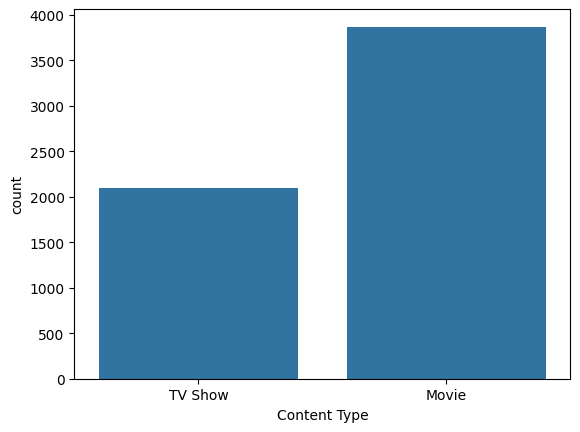

In [39]:
sns.countplot(data=df, x='Content Type',)

<Axes: xlabel='Genres'>

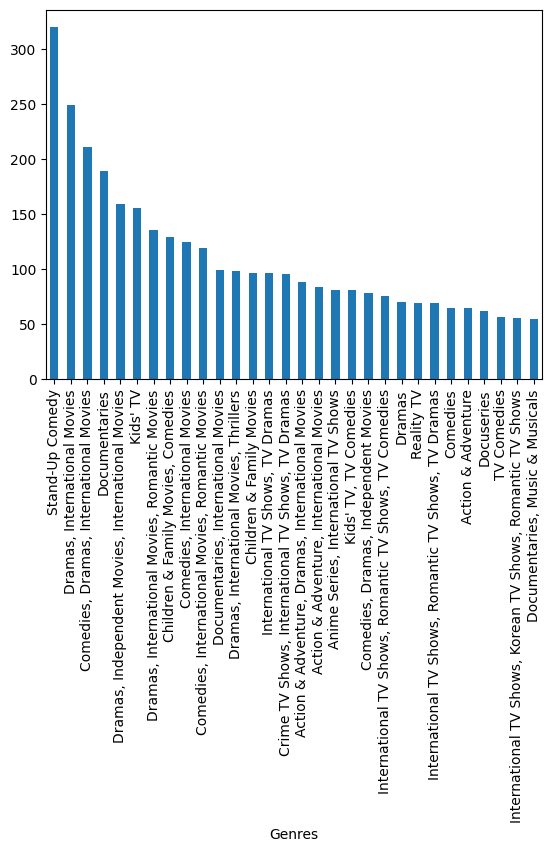

In [40]:
#which type of genres mostly making
df['Genres'].value_counts().head(30).plot(kind='bar')

In [41]:
#top genres
#stand_up comedy are mostly in making
df['Genres'].value_counts()


Genres
Stand-Up Comedy                                            320
Dramas, International Movies                               249
Comedies, Dramas, International Movies                     211
Documentaries                                              189
Dramas, Independent Movies, International Movies           159
                                                          ... 
Action & Adventure, International Movies, Sports Movies      1
LGBTQ Movies, Thrillers                                      1
Children & Family Movies, Classic Movies, Comedies           1
Kids' TV, Reality TV, Science & Nature TV                    1
Cult Movies, Dramas, Music & Musicals                        1
Name: count, Length: 433, dtype: int64

<Axes: xlabel='Production Country'>

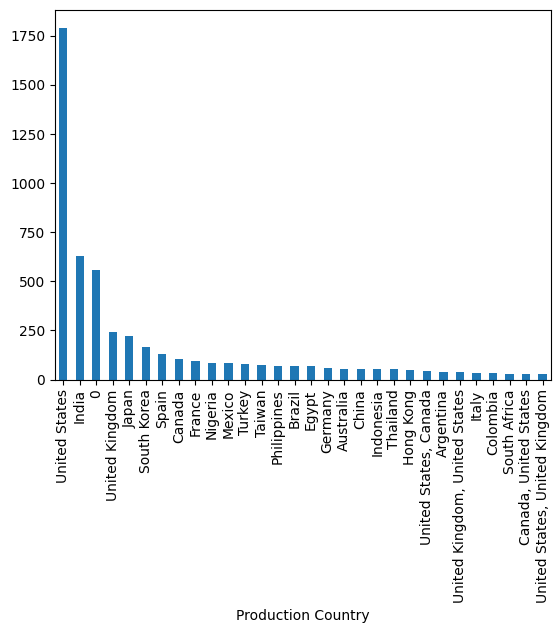

In [42]:
#which country produce most movies
df['Production Country'].value_counts().head(30).plot(kind='bar')

In [43]:
df['Production Country'].value_counts()
#US produce most movies

Production Country
United States                                                   1792
India                                                            628
0                                                                559
United Kingdom                                                   244
Japan                                                            221
                                                                ... 
United Kingdom, Spain                                              1
Romania, Bulgaria, Hungary                                         1
United Kingdom, Ukraine, United States                             1
China, United States, Canada                                       1
Sweden, Czech Republic, United Kingdom, Denmark, Netherlands       1
Name: count, Length: 510, dtype: int64

In [44]:
#in which year most of  the movies released
df['Release Year'].value_counts()
#2019 is the year most of the movies release

Release Year
2019    971
2020    946
2018    927
2017    661
2016    491
       ... 
1962      1
1963      1
1960      1
1970      1
1959      1
Name: count, Length: 65, dtype: int64

<Axes: xlabel='Release Year'>

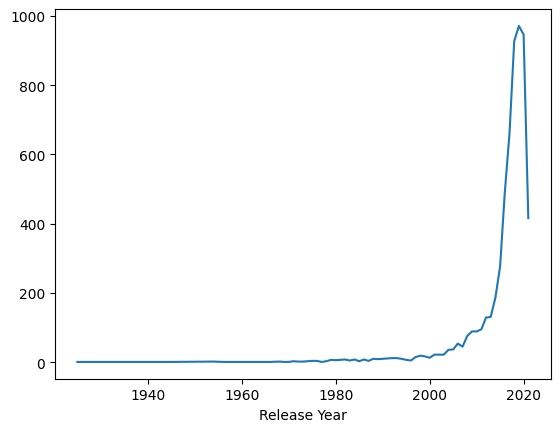

In [45]:
#show in plot
df['Release Year'].value_counts().sort_index().plot()

<Axes: xlabel='Added Year'>

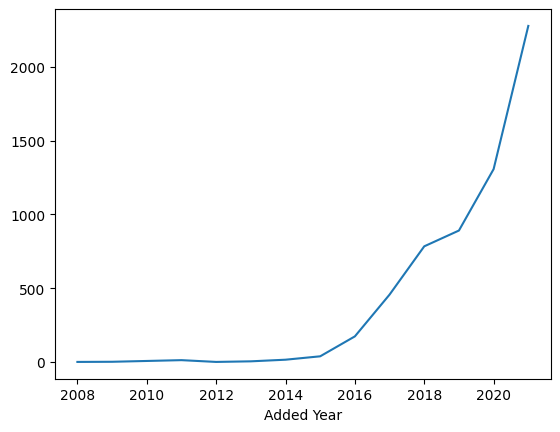

In [46]:
#in which year most of the movies added plot
df['Added Year'].value_counts().sort_index().plot()


In [47]:
#in which year most of the movies added
df['Added Year'].value_counts()
#movies are mostly added in 2021

Added Year
2021    2277
2020    1307
2019     891
2018     784
2017     457
2016     174
2015      39
2014      16
2011      13
2013       5
2009       2
2012       1
2008       1
Name: count, dtype: int64

In [48]:
#mostly movies score lies between 6.somthing
df['Imdb Score'].mean()

np.float64(6.57335344394168)

<Axes: xlabel='Imdb Score', ylabel='Count'>

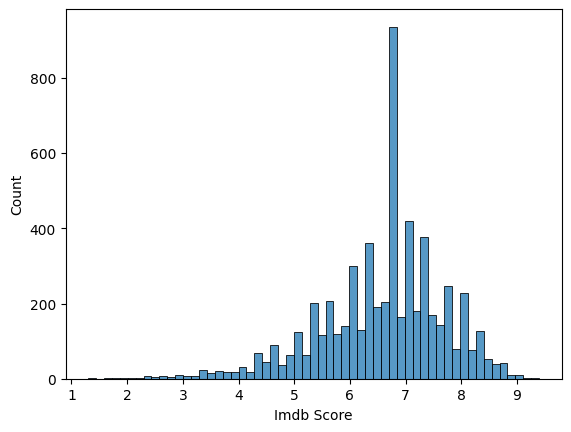

In [49]:
#in histogram
sns.histplot(x=df['Imdb Score'])

<Axes: xlabel='Duration', ylabel='Count'>

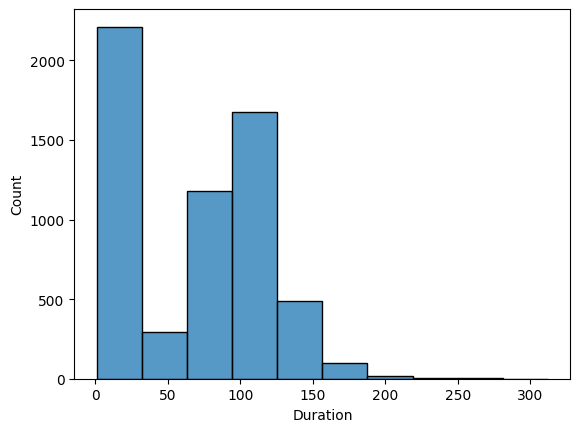

In [50]:
#duration of movies
sns.histplot(df['Duration'],bins=10)

In [51]:
df['Duration'].mean()
#average duration  lies between 64 minutes

np.float64(64.94603653427183)

In [52]:
# Average rating of movies
#average rating of movies are 6
df.groupby('Rating')['Imdb Score'].mean()


Rating
G        6.180000
NC-17    6.000000
PG       6.236000
PG-13    6.316814
R        6.230649
TV-14    6.607930
TV-G     6.485616
TV-MA    6.650334
TV-PG    6.613472
TV-Y     6.523750
TV-Y7    6.537379
Name: Imdb Score, dtype: float64

In [53]:
# average quality of movies and Tv_shows
#Tv shows are most likely in peoples
df.groupby('Content Type')['Imdb Score'].mean()

Content Type
Movie      6.301371
TV Show    7.074190
Name: Imdb Score, dtype: float64

<Axes: xlabel='Content Type', ylabel='Imdb Score'>

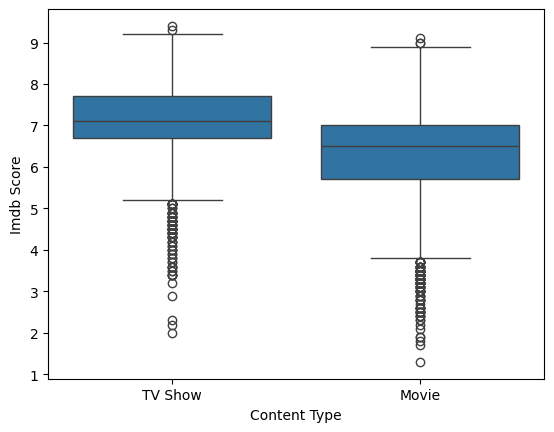

In [54]:
#in graph
sns.boxplot(data=df, x='Content Type', y='Imdb Score')

In [55]:
#Average Duration of movie
df[df['Content Type']=="Movie"]['Duration'].mean()

np.float64(99.19162141194725)

In [56]:
#Director
df['Director'].value_counts()

Director
0                         2064
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 15
Jay Karas                   14
                          ... 
Luis Valdez                  1
Josef Fares                  1
Sam Dunn                     1
Hong-seon Kim                1
Young Jun Lee                1
Name: count, Length: 2994, dtype: int64

In [57]:
#best genres
df.groupby('Genres')['Imdb Score'].mean().sort_values(ascending=False).head(20)

Genres
Classic & Cult TV, Kids' TV, TV Action & Adventure                        9.300000
British TV Shows, Classic & Cult TV, International TV Shows               8.733333
TV Action & Adventure, TV Horror, TV Sci-Fi & Fantasy                     8.600000
British TV Shows, International TV Shows, Stand-Up Comedy & Talk Shows    8.500000
Action & Adventure, Classic Movies, Sci-Fi & Fantasy                      8.500000
British TV Shows, Romantic TV Shows, TV Dramas                            8.400000
Crime TV Shows, TV Action & Adventure, TV Thrillers                       8.400000
International TV Shows, TV Action & Adventure, TV Mysteries               8.350000
Classic Movies, Cult Movies, Dramas                                       8.300000
Crime TV Shows, TV Comedies, Teen TV Shows                                8.300000
Romantic TV Shows, TV Action & Adventure, TV Dramas                       8.300000
British TV Shows, Classic & Cult TV, TV Comedies                          8.3000

In [58]:
#cast impact
#so cast impact is negative  more cast does effact the score
df[['Cast Count','Imdb Score']].corr()

,Cast Count,Imdb Score
Cast Count,1.000000,-0.042836
Imdb Score,-0.042836,1.000000


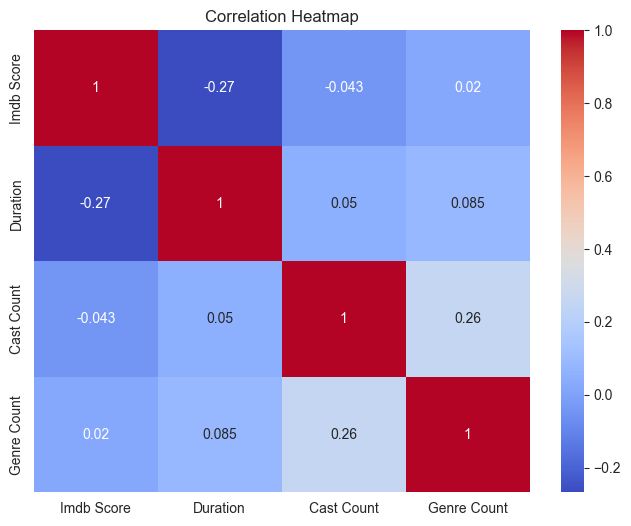

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Imdb Score','Duration','Cast Count','Genre Count']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [60]:
'''
long duration affect the score
no of count cast does not  affect the score much
Genres does not affect the score
according to duration cast count and genres count  is ok
genres and cast count is ok
Movies with more genres tend to have slightly more actors
Most correlations are very weak, so these features don’t strongly influence each other.
The only somewhat meaningful relationship is:
 More genres → slightly more cast members
'''

'\nlong duration affect the score\nno of count cast does not  affect the score much\nGenres does not affect the score\naccording to duration cast count and genres count  is ok\ngenres and cast count is ok\nMovies with more genres tend to have slightly more actors\nMost correlations are very weak, so these features don’t strongly influence each other.\nThe only somewhat meaningful relationship is:\n More genres → slightly more cast members\n'

In [61]:
'''
INSIGHTS

Movies dominate TV Shows in dataset
USA produces most content
Most content is in Drama / International genres
IMDb scores mostly lie between 5–8
Content production increased after 2010
TV Shows are growing in recent years
Missing values exist mostly in Cast, Director, Country
'''

'\nINSIGHTS\n\nMovies dominate TV Shows in dataset\nUSA produces most content\nMost content is in Drama / International genres\nIMDb scores mostly lie between 5–8\nContent production increased after 2010\nTV Shows are growing in recent years\nMissing values exist mostly in Cast, Director, Country\n'

In [62]:
'''“I performed data cleaning by handling missing values, fixing IMDb score and date columns. Then I performed univariate, bivariate, and time-based analysis to understand content trends, ratings, and production patterns. Finally, I extracted insights about genre popularity, country contribution, and Netflix content growth over time.”'''

'“I performed data cleaning by handling missing values, fixing IMDb score and date columns. Then I performed univariate, bivariate, and time-based analysis to understand content trends, ratings, and production patterns. Finally, I extracted insights about genre popularity, country contribution, and Netflix content growth over time.”'